In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("parkinsons.data")

In [3]:
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Shape: {df.shape}")
print(f"\nColumns:\n{list(df.columns)}")
print(f"\nFirst 3 rows:\n{df.head(3)}")

DATASET OVERVIEW
Shape: (195, 24)

Columns:
['name', 'MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'status', 'RPDE', 'DFA', 'spread1', 'spread2', 'D2', 'PPE']

First 3 rows:
             name  MDVP:Fo(Hz)  MDVP:Fhi(Hz)  MDVP:Flo(Hz)  MDVP:Jitter(%)  \
0  phon_R01_S01_1      119.992       157.302        74.997         0.00784   
1  phon_R01_S01_2      122.400       148.650       113.819         0.00968   
2  phon_R01_S01_3      116.682       131.111       111.555         0.01050   

   MDVP:Jitter(Abs)  MDVP:RAP  MDVP:PPQ  Jitter:DDP  MDVP:Shimmer  ...  \
0           0.00007   0.00370   0.00554     0.01109       0.04374  ...   
1           0.00008   0.00465   0.00696     0.01394       0.06134  ...   
2           0.00009   0.00544   0.00781     0.01633       0.05233  ...   

   Shimmer:DDA      NHR     HN

In [4]:
print("\n" + "=" * 50)
print("NULL VALUES")
print("=" * 50)
print(df.isnull().sum())


NULL VALUES
name                0
MDVP:Fo(Hz)         0
MDVP:Fhi(Hz)        0
MDVP:Flo(Hz)        0
MDVP:Jitter(%)      0
MDVP:Jitter(Abs)    0
MDVP:RAP            0
MDVP:PPQ            0
Jitter:DDP          0
MDVP:Shimmer        0
MDVP:Shimmer(dB)    0
Shimmer:APQ3        0
Shimmer:APQ5        0
MDVP:APQ            0
Shimmer:DDA         0
NHR                 0
HNR                 0
status              0
RPDE                0
DFA                 0
spread1             0
spread2             0
D2                  0
PPE                 0
dtype: int64


In [5]:
print("\n" + "=" * 50)
print("CLASS BALANCE")
print("=" * 50)
print(df["status"].value_counts())
print(f"Parkinson's: {df['status'].sum()} | Healthy: {(df['status'] == 0).sum()}")


CLASS BALANCE
status
1    147
0     48
Name: count, dtype: int64
Parkinson's: 147 | Healthy: 48


In [6]:
print("\n" + "=" * 50)
print("FEATURE STATISTICS")
print("=" * 50)
print(df.describe().T[["mean", "std", "min", "max"]])


FEATURE STATISTICS
                        mean        std         min         max
MDVP:Fo(Hz)       154.228641  41.390065   88.333000  260.105000
MDVP:Fhi(Hz)      197.104918  91.491548  102.145000  592.030000
MDVP:Flo(Hz)      116.324631  43.521413   65.476000  239.170000
MDVP:Jitter(%)      0.006220   0.004848    0.001680    0.033160
MDVP:Jitter(Abs)    0.000044   0.000035    0.000007    0.000260
MDVP:RAP            0.003306   0.002968    0.000680    0.021440
MDVP:PPQ            0.003446   0.002759    0.000920    0.019580
Jitter:DDP          0.009920   0.008903    0.002040    0.064330
MDVP:Shimmer        0.029709   0.018857    0.009540    0.119080
MDVP:Shimmer(dB)    0.282251   0.194877    0.085000    1.302000
Shimmer:APQ3        0.015664   0.010153    0.004550    0.056470
Shimmer:APQ5        0.017878   0.012024    0.005700    0.079400
MDVP:APQ            0.024081   0.016947    0.007190    0.137780
Shimmer:DDA         0.046993   0.030459    0.013640    0.169420
NHR                 

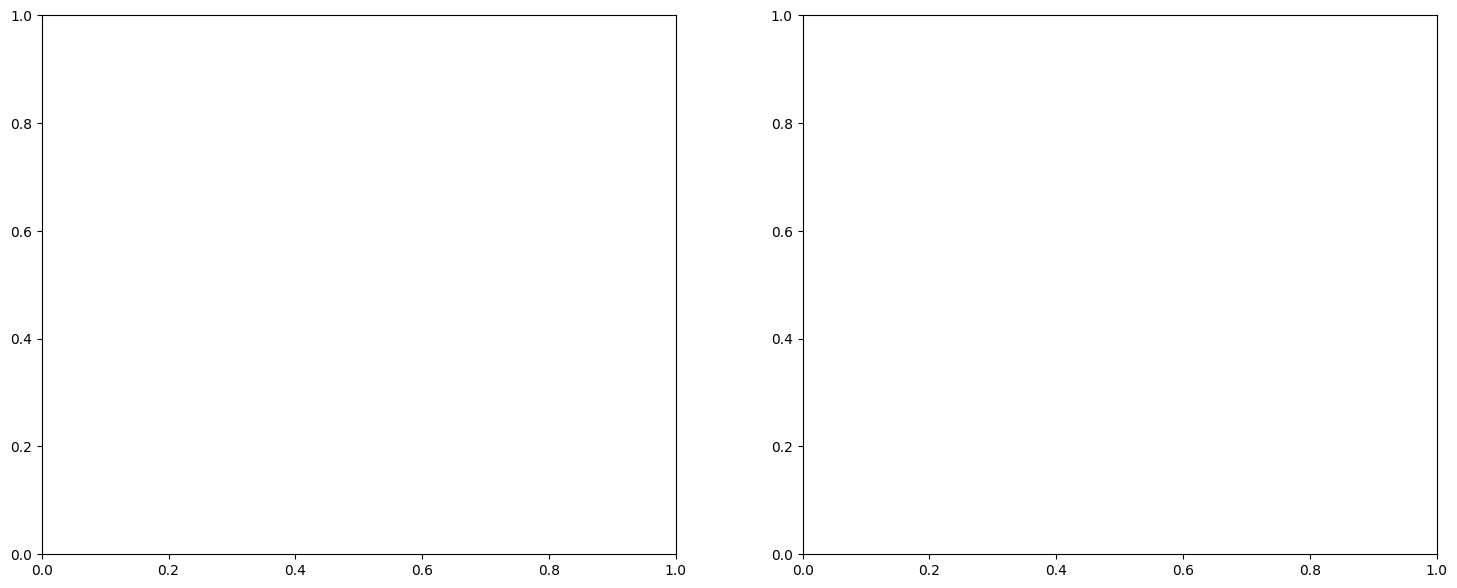

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

In [11]:
features = df.drop(columns=["name", "status"])
corr = features.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0,
            linewidths=0.3, ax=axes[0], cbar_kws={"shrink": 0.8})
axes[0].set_title("Feature Correlation Heatmap", fontsize=13)
axes[0].tick_params(labelsize=7)

In [12]:
status_counts = df["status"].value_counts()
axes[1].bar(["Healthy (0)", "Parkinson's (1)"],
            status_counts.values,
            color=["#4C9BE8", "#E8593C"], width=0.5)
axes[1].set_title("Class Distribution", fontsize=13)
axes[1].set_ylabel("Count")
for i, v in enumerate(status_counts.values):
    axes[1].text(i, v + 1, str(v), ha="center", fontweight="bold")
 
plt.tight_layout()
plt.savefig("eda_plots.png", dpi=120, bbox_inches="tight")
plt.show()
print("\nPlot saved as eda_plots.png")

<Figure size 640x480 with 0 Axes>


Plot saved as eda_plots.png


In [13]:
print("\n" + "=" * 50)
print("TOP 10 FEATURES CORRELATED WITH STATUS")
print("=" * 50)
corr_with_target = df.drop(columns=["name"]).corr()["status"].drop("status")
print(corr_with_target.abs().sort_values(ascending=False).head(10))


TOP 10 FEATURES CORRELATED WITH STATUS
spread1             0.564838
PPE                 0.531039
spread2             0.454842
MDVP:Fo(Hz)         0.383535
MDVP:Flo(Hz)        0.380200
MDVP:Shimmer        0.367430
MDVP:APQ            0.364316
HNR                 0.361515
Shimmer:APQ5        0.351148
MDVP:Shimmer(dB)    0.350697
Name: status, dtype: float64


In [14]:
import pandas as pd
import numpy as np
import joblib
import os
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score
)

In [15]:
df = df.drop(columns=["name"])

In [16]:
X = df.drop(columns=["status"])
y = df["status"]

In [17]:
FEATURE_NAMES = list(X.columns)

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [19]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)


In [21]:
print("=" * 50)
print("SVM RESULTS")
print("=" * 50)
 
param_grid = {
    "C":     [0.1, 1, 10, 100],
    "gamma": ["scale", "auto", 0.01, 0.001],
    "kernel": ["rbf"]
}
svm_grid = GridSearchCV(SVC(probability=True, random_state=42),
                        param_grid, cv=5, scoring="accuracy", n_jobs=-1)
svm_grid.fit(X_train_sc, y_train)
svm_best = svm_grid.best_estimator_
 
print(f"Best params: {svm_grid.best_params_}")
y_pred_svm = svm_best.predict(X_test_sc)
print(f"Test Accuracy : {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"ROC-AUC       : {roc_auc_score(y_test, svm_best.predict_proba(X_test_sc)[:,1]):.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred_svm)}")

SVM RESULTS
Best params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Test Accuracy : 0.8974
ROC-AUC       : 0.9621

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.80      0.80        10
           1       0.93      0.93      0.93        29

    accuracy                           0.90        39
   macro avg       0.87      0.87      0.87        39
weighted avg       0.90      0.90      0.90        39



In [22]:
cv_svm = cross_val_score(svm_best, X_train_sc, y_train, cv=5, scoring="accuracy")
print(f"5-Fold CV Mean: {cv_svm.mean():.4f} ± {cv_svm.std():.4f}")

5-Fold CV Mean: 0.9296 ± 0.0235


In [23]:
print("\n" + "=" * 50)
print("RANDOM FOREST RESULTS")
print("=" * 50)
 
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)   # RF doesn't need scaling
y_pred_rf = rf.predict(X_test)
print(f"Test Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC       : {roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]):.4f}")


RANDOM FOREST RESULTS
Test Accuracy : 0.9231
ROC-AUC       : 0.9621


In [25]:
feat_imp = pd.Series(rf.feature_importances_, index=FEATURE_NAMES)
print(f"\nTop 5 important features:\n{feat_imp.sort_values(ascending=False).head(5)}")


Top 5 important features:
PPE            0.150716
spread1        0.109254
MDVP:Fo(Hz)    0.060157
Jitter:DDP     0.057883
NHR            0.056363
dtype: float64


In [26]:
os.makedirs("model", exist_ok=True)
joblib.dump(svm_best,      "model/parkinsons_model.pkl")
joblib.dump(scaler,        "model/scaler.pkl")
joblib.dump(FEATURE_NAMES, "model/feature_names.pkl")

['model/feature_names.pkl']

In [28]:
print("\n" + "=" * 50)
print("FILES SAVED")
print("=" * 50)
print("  model/parkinsons_model.pkl")
print("  model/scaler.pkl")
print("  model/feature_names.pkl")
print("\nRun this once locally, then commit the model/ folder to GitHub.")


FILES SAVED
  model/parkinsons_model.pkl
  model/scaler.pkl
  model/feature_names.pkl

Run this once locally, then commit the model/ folder to GitHub.
